In [18]:
from helpers.sporc import (
    SPORCDataset
)
from pprint import pprint
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd
import string
from nltk.corpus import stopwords
import hdbscan
import networkx as nx
import random

In [3]:
sporc = SPORCDataset(local_data_dir="data", load_samples_only=True)

INFO:helpers.sporc.dataset:Loading SPORC dataset from local directory: data
INFO:helpers.sporc.dataset:Loading SPORC sample dataset only.
INFO:helpers.sporc.dataset:✓ All required files found
INFO:helpers.sporc.dataset:Loading all records from local files into memory...
INFO:helpers.sporc.dataset:Loading episode_data_sample...
INFO:helpers.sporc.dataset:Loading speaker_turn_data_sample...
INFO:helpers.sporc.dataset:✓ Loaded 210,000 total records from 2 files
INFO:helpers.sporc.dataset:✓ Local dataset loaded successfully in 10.50 seconds
INFO:helpers.sporc.dataset:✓ Dataset loaded successfully with 210000 total records
INFO:helpers.sporc.dataset:Processing dataset into Podcast and Episode objects...
INFO:helpers.sporc.dataset:Separating episode data from speaker turn data...


Loading episodes:   0%|          | 0/210000 [00:00<?, ?it/s]

INFO:helpers.sporc.dataset:✓ Separation completed in 0.69 seconds
INFO:helpers.sporc.dataset:  Episode records: 10,000, Speaker turn records: 200,000
INFO:helpers.sporc.dataset:Grouping episodes by podcast...
INFO:helpers.sporc.dataset:✓ Grouping completed in 0.05 seconds
INFO:helpers.sporc.dataset:  Episodes grouped into 1826 podcasts
INFO:helpers.sporc.dataset:Creating Podcast and Episode objects...
INFO:helpers.sporc.dataset:✓ Object creation completed in 2.16 seconds
INFO:helpers.sporc.dataset:Loading speaker turn data for episodes...
INFO:helpers.sporc.dataset:Loading turn data for 200,000 speaker turn records...
INFO:helpers.sporc.dataset:Grouping turns by episode URL...
INFO:helpers.sporc.dataset:✓ Turn grouping completed in 0.21 seconds
INFO:helpers.sporc.dataset:  Turns grouped into 1,033 episodes
INFO:helpers.sporc.dataset:Loading turns for each episode...
INFO:helpers.sporc.dataset:✓ Turn loading completed in 2.33 seconds
INFO:helpers.sporc.dataset:  Episodes with turns: 1,0

## Preprocessing and data pipeline

In [4]:
stop_words = set(stopwords.words("english"))

def starts_with_upper(s):
    if not s:          # empty string
        return False
    if s[0].isspace(): # skip whitespace
        return starts_with_upper(s[1:])
    return s[0].isupper()

def keep_interruption(s):
    
    # remove pure punctuation
    if all(ch in string.punctuation or ch.isspace() for ch in s):
        return False
    
    #if not starts_with_upper(s): #starts with lowercase letter
    #    return False

    return True

In [ ]:
episodes = sporc.get_all_episodes()

interruption_events = [] #for graph
interruptions = []         
interruptions_per_episode = []  
categories_per_episode = []
episode_id = []

for idx, episode in enumerate(episodes):
    turns = episode.get_all_turns()
    categories = episode.categories
    categories_per_episode.append(categories)
    

    count = 0

    for i in range(len(turns) - 1):
        cur = turns[i]
        nxt = turns[i+1]
        
        # interruption rule
        if cur.end_time > nxt.start_time and cur.speaker != nxt.speaker:
            if keep_interruption(nxt.text):
                interruptions.append(nxt.text)
                episode_id.append(idx)
                count += 1
                
                #only add if one of the turns have inferred speaker names
                if cur.inferred_speaker_name != 'NO_INFERRED_SPEAKER' or nxt.inferred_speaker_name != 'NO_INFERRED_SPEAKER':
                    interruption_events.append({
                        "interrupter": nxt.inferred_speaker_name,
                        "interrupted": cur.inferred_speaker_name,
                    })
    interruptions_per_episode.append(count)

print("Total interruptions found:", len(interruptions))


Total interruptions found: 206
206


## Relevant visualizations of interruptions

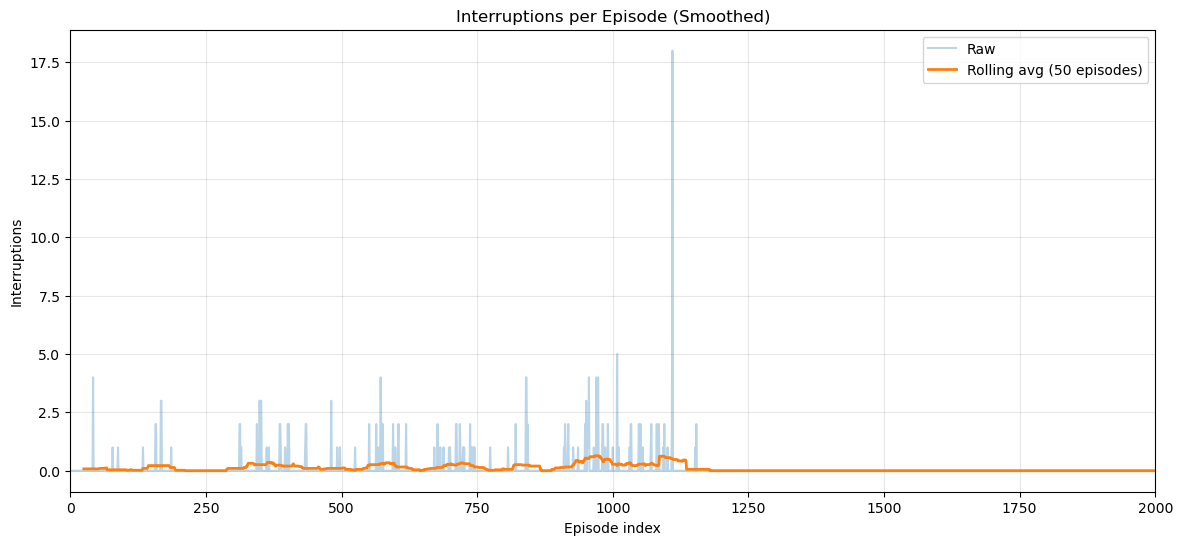

In [6]:
#plot of interruptions per episode
s = pd.Series(interruptions_per_episode)
rolling = s.rolling(window=50, center=True).mean()

plt.figure(figsize=(14, 6))
plt.plot(s, alpha=0.3, label="Raw")
plt.plot(rolling, linewidth=2, label="Rolling avg (50 episodes)")

plt.title("Interruptions per Episode (Smoothed)")
plt.xlabel("Episode index")
plt.ylabel("Interruptions")
plt.xlim(0, 2000)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



===== Average Interruptions per Category =====
categories
soccer         0.254545
social         0.187500
improv         0.130435
baseball       0.128440
basketball     0.111111
video games    0.096774
commentary     0.072289
comedy         0.069909
games          0.069307
hobbies        0.062112
Name: interruptions, dtype: float64

===== Total Interruptions per Category =====
categories
sports              57
comedy              46
education           32
health              23
leisure             19
mental              17
self improvement    17
society             16
music               16
culture             16
Name: interruptions, dtype: int64

===== Number of Episodes per Category =====
categories
religion        2109
spirituality    2106
society         1609
culture         1609
business        1493
education       1486
christianity    1223
health          1041
fitness         1007
sports           971
Name: count, dtype: int64


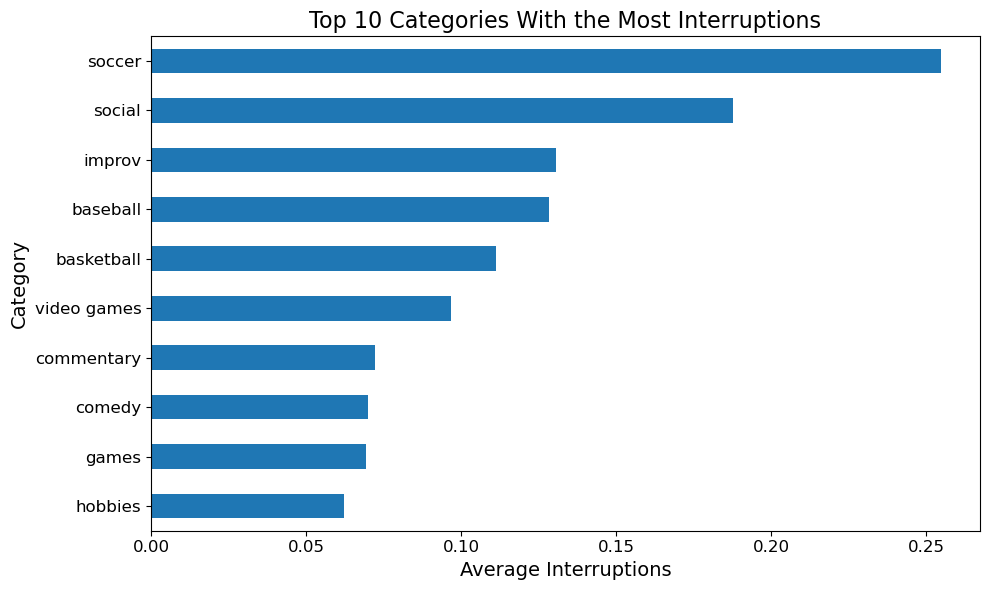

In [7]:
#Interruption across categories analysis
df = pd.DataFrame({
    "episode": range(len(episodes)),
    "categories": categories_per_episode,
    "interruptions": interruptions_per_episode
})

# Explode categories into separate rows
df_exploded = df.explode("categories")
df_exploded = df_exploded[df_exploded["categories"].str.strip() != ""]

print("\n===== Average Interruptions per Category =====")
category_mean = df_exploded.groupby("categories")["interruptions"].mean().sort_values(ascending=False).head(10)
print(category_mean)

print("\n===== Total Interruptions per Category =====")
category_sum = df_exploded.groupby("categories")["interruptions"].sum().sort_values(ascending=False).head(10)
print(category_sum)

print("\n===== Number of Episodes per Category =====")
category_counts = df_exploded["categories"].value_counts().head(10)
print(category_counts)

# Select top 10
top_10 = category_mean.head(10)
# Plot
plt.figure(figsize=(10, 6))
top_10.sort_values().plot(kind="barh", fontsize=12)
plt.title("Top 10 Categories With the Most Interruptions", fontsize=16)
plt.xlabel("Average Interruptions", fontsize=14)
plt.ylabel("Category", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# find the top interrupters and interrupted
df = pd.DataFrame(interruption_events)
df = df[df["interrupter"] != "NO_INFERRED_SPEAKER"]

edges = (
  df.groupby(["interrupter", "interrupted"])
    .size()
    .reset_index(name="count")
)

top_n = 10
outgoing = edges.groupby("interrupter")["count"].sum().sort_values(ascending=False)
top_interrupters = set(outgoing.head(top_n).index)
#print top interrupters and their counts
print("\n===== Top Interrupters =====")
pprint(outgoing.head(top_n).to_dict())



===== Top Interrupters =====
{'Jeff Crisman': 1,
 'Jimi Grankey': 1,
 'Michael Rosenbaum': 1,
 'Rob Manifield': 1,
 'Scott Phillips': 2,
 'Tim Kelly': 2,
 'Tom Joel': 1}


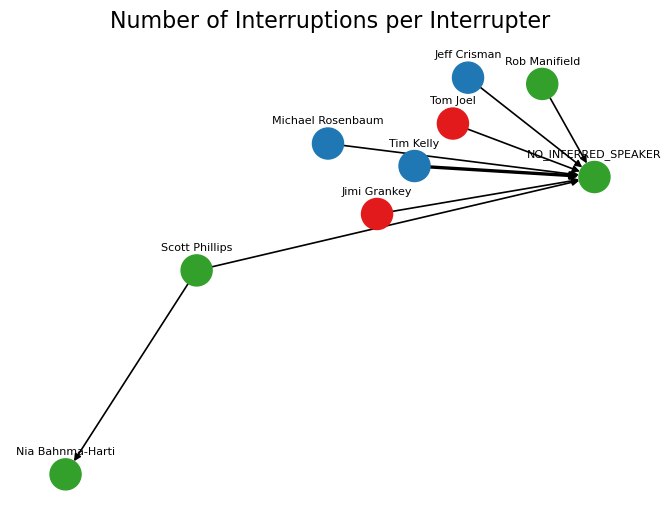

In [21]:
#plot of the number of interruptions per interrupter
G = nx.DiGraph()
for row in edges.itertuples():
    G.add_edge(row.interrupter, row.interrupted, weight=row.count)

pos = nx.spring_layout(G, seed=42)
color_options = ['#1f78b4', '#33a02c', '#e31a1c']
node_colors = [random.choice(color_options) for _ in G.nodes()]
#{node: (node if node in top_interrupters else "") for node in G.nodes()}
labels = {node: node for node in G.nodes()}
nx.draw(
    G, pos,
    with_labels=False,      
    arrows=True,
    node_size=500,
    node_color=node_colors,
    width=[d["weight"] * 1.2 for (_,_,d) in G.edges(data=True)]
)

for node, (x, y) in pos.items():
    plt.text(
        x, y + 0.08,   
        labels[node],
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=8
    )

plt.title("Number of Interruptions per Interrupter", fontsize=16)
plt.xlabel("Interrupter", fontsize=14)
plt.ylabel("Interrupted", fontsize=14)
plt.show()


## Clustering of interruptions

In [10]:
#sentence embeddings
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
embeddings = model.encode(interruptions)
print(embeddings.shape)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-mpnet-base-v2


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

(206, 768)


In [26]:
# Step 1: Dimensionality reduction
pca = PCA(n_components=10, random_state=42) #change to higher dimensions if needed
reduced_embeddings = pca.fit_transform(embeddings)

# Step 2: Compute silhouette scores on reduced embeddings
def evaluate_k_range(X, k_min=3, k_max=15):
    scores = {}
    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores[k] = score
    return scores

scores = evaluate_k_range(reduced_embeddings)

# Step 3: Pick k with highest silhouette score and cluster
k = max(scores, key=scores.get)
print(f"Chosen k = {k} with silhouette score = {scores[k]:.4f}")
print("")
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(reduced_embeddings)

# Step 4: Print cluster assignments
for text, label in zip(interruptions[:10], kmeans_labels[:10]):
    print(f"[Cluster {label}] {text}")


Chosen k = 3 with silhouette score = 0.1844

[Cluster 2] , failed it at schoolcraft, failed it once at Eastern, and then, uh, who got, I think I, uh, I won, like, had to do a placement test and I, uh, completed the placement test by one point and each question was worth seven points, so God knows how I did that. And then, uh, I took an online class so I could cheat, because I knew I wasn't going to pass it. Yeah, you got a, you got a cheat. Yeah, I took the baby, baby math in college. Like, the final project was like writing a yearly budget. [laughter] He's not like the starting salary for your career. It was so easy. It was like trash math, but like, it counted. Um, yeah, if you fail it three times, that's, that's, that's when it becomes a hobby. Yeah, that point skateboarding is just a hobby. [laughter] Yeah, what we were saying earlier is skateboarding is a way to express myself. Okay. Dan, Dan, Kev, yelling at it. Dad, this is how I express myself. Yeah. I throw myself at concrete 

In [ ]:
#interpret cluster centers
cluster_centers = kmeans.cluster_centers_
for c in range(k):
    print(f"\nCluster {c} examples:")
    idxs = np.where(kmeans_labels == c)[0][:2] # show 2 examples per cluster
    for i in idxs[:10]:
        print("  ", interruptions[i])


Cluster 0 examples:
    of these. Hold on. Let me make sure none of these are sexual. I'm pretty sure none of them are. It's for
    Don

Cluster 1 examples:
    And then he comes back the next year, does Space Jam, works out like a bad man and just comes back in absolute beast. So yeah, I'd be taking that first year back MJ. And then Kevin Durant. I'm going to be taking him since you took LeBron James. I need the LeBron James beater. And that's Kevin Durant. And specifically the 2017-2018 Kevin Durant got the finals MVP against LeBron all NBA first team. Yeah, there's a 26, 6 and 5. It's got for almost 42% from 3 and over 50% from the field, which for someone who's not a big, that's just ridiculous. You know, I already know that Kevin Durant's okay with not being the number one option on a team. And so putting him next. Yes. Yes. Because he's just there to ball. That version maybe. Yeah. That
    Yeah. So I'd be taking that first full year that he has back because he's like, it's the

In [13]:
#t-SNE visualization of clusters
def plot_clustering(embeddings, labels, dims=2, texts=None, perplexity=30, random_state=42):
    """
    Visualizes sentence clusters using t-SNE in 2D or 3D.

    Parameters:
    - embeddings: numpy array of shape (n_samples, n_features)
    - labels: list or array of cluster labels
    - dims: 2 or 3 (number of t-SNE output dimensions)
    - texts: optional list of sentences (used only for 3D tooltips)
    - perplexity: t-SNE perplexity
    - random_state: random seed for reproducibility
    """

    if dims not in [2, 3]:
        raise ValueError("dims must be 2 or 3.")

    tsne = TSNE(
        n_components=dims,
        perplexity=perplexity,
        random_state=random_state
    )

    projections = tsne.fit_transform(embeddings)

    # ---------------------- 2D PLOT ----------------------
    if dims == 2:
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(
            projections[:, 0],
            projections[:, 1],
            c=labels,
            s=50,
            alpha=0.8
        )
        plt.title("t-SNE Clustering (2D)")
        plt.xlabel("TSNE-1")
        plt.ylabel("TSNE-2")
        plt.show()

    # ---------------------- 3D PLOT ----------------------
    else:
        if texts is None:
            texts = [""] * len(labels)

        df_plot = pd.DataFrame({
            "x": projections[:, 0],
            "y": projections[:, 1],
            "z": projections[:, 2],
            "cluster": labels,
            "text": texts
        })

        fig = px.scatter_3d(
            df_plot, 
            x='x', y='y', z='z',
            color='cluster',
            hover_name='text',
            labels={'color': 'cluster'}
        )
        fig.update_traces(marker_size=4)
        fig.update_layout(title="t-SNE Clustering (3D)")
        fig.show()

In [ ]:
plot_clustering(reduced_embeddings, kmeans_labels, dims=3, texts=interruptions)

In [22]:
# DBSCAN clustering
clusterer = hdbscan.HDBSCAN(
    
)
dbscan_labels = clusterer.fit_predict(reduced_embeddings)

def evaluate_dbscan(X, labels, clusterer=None):
    print("\n========== DBSCAN / HDBSCAN Evaluation ==========\n")

    # -------------------------------
    # Basic Stats
    # -------------------------------
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    print(f"Clusters found (excluding noise): {n_clusters}")
    print(f"Noise ratio: {noise_ratio:.3f}")

    # -------------------------------
    # Silhouette (excluding noise)
    # -------------------------------
    mask = labels != -1
    if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
        print(f"Silhouette score (no noise): {sil:.4f}")
    else:
        print("Silhouette score: Not enough clusters (need ≥2).")

    # -------------------------------
    # HDBSCAN-specific metrics
    # -------------------------------
    if clusterer is not None and hasattr(clusterer, "cluster_persistence_"):

        persistence = clusterer.cluster_persistence_
        print("\n--- HDBSCAN Cluster Stability Scores ---")

        # Case 1 — dict
        if isinstance(persistence, dict):
            for cid, stability in persistence.items():
                print(f"Cluster {cid}: stability = {stability:.2f}")

        # Case 2 — structured array (has dtype names)
        elif isinstance(persistence, np.ndarray) and persistence.dtype.names is not None:
            # structured array fields may be ('cluster', 'persistence')
            cid_field = persistence.dtype.names[0]
            stab_field = persistence.dtype.names[1]
            for row in persistence:
                print(f"Cluster {row[cid_field]}: stability = {row[stab_field]:.2f}")

        # Case 3 — plain 1D numpy array (stability only)
        elif isinstance(persistence, np.ndarray) and persistence.dtype.names is None:
            for i, stability in enumerate(persistence):
                print(f"Cluster {i}: stability = {stability:.2f}")

        else:
            print("Unknown cluster_persistence_ format.")


        # ---- Outlier scores ----
        if hasattr(clusterer, "outlier_scores_"):
            print("\n--- HDBSCAN Outlier Analysis ---")
            print(f"Mean outlier score: {np.mean(clusterer.outlier_scores_):.4f}")

    print("\n=================================================\n")

    
evaluate_dbscan(reduced_embeddings, dbscan_labels, clusterer=clusterer)


========== DBSCAN / HDBSCAN Evaluation ==========

Clusters found (excluding noise): 3
Noise ratio: 0.587
Silhouette score (no noise): 0.2691

--- HDBSCAN Cluster Stability Scores ---
Cluster 0: stability = 0.11
Cluster 1: stability = 0.13
Cluster 2: stability = 0.01

--- HDBSCAN Outlier Analysis ---
Mean outlier score: 0.1298




/Users/mikkel/miniconda3/envs/exam/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/mikkel/miniconda3/envs/exam/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [23]:
plot_clustering(reduced_embeddings, dbscan_labels, dims=3, texts=interruptions)

## Feature Extraction

category,arts,baseball,basketball,business,careers,christianity,comedy,commentary,courses,culture,...,social,society,spirituality,sports,technology,travel,tv,video games,visual,Total Interruptions
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,4,5,0,5,0,2,18,3,0,5,...,3,5,2,19,0,1,3,6,0,194
1,0,5,2,4,0,0,2,0,0,0,...,0,0,0,23,0,0,2,1,0,53
2,8,4,0,5,2,1,26,3,1,11,...,3,11,2,15,1,1,6,5,1,236


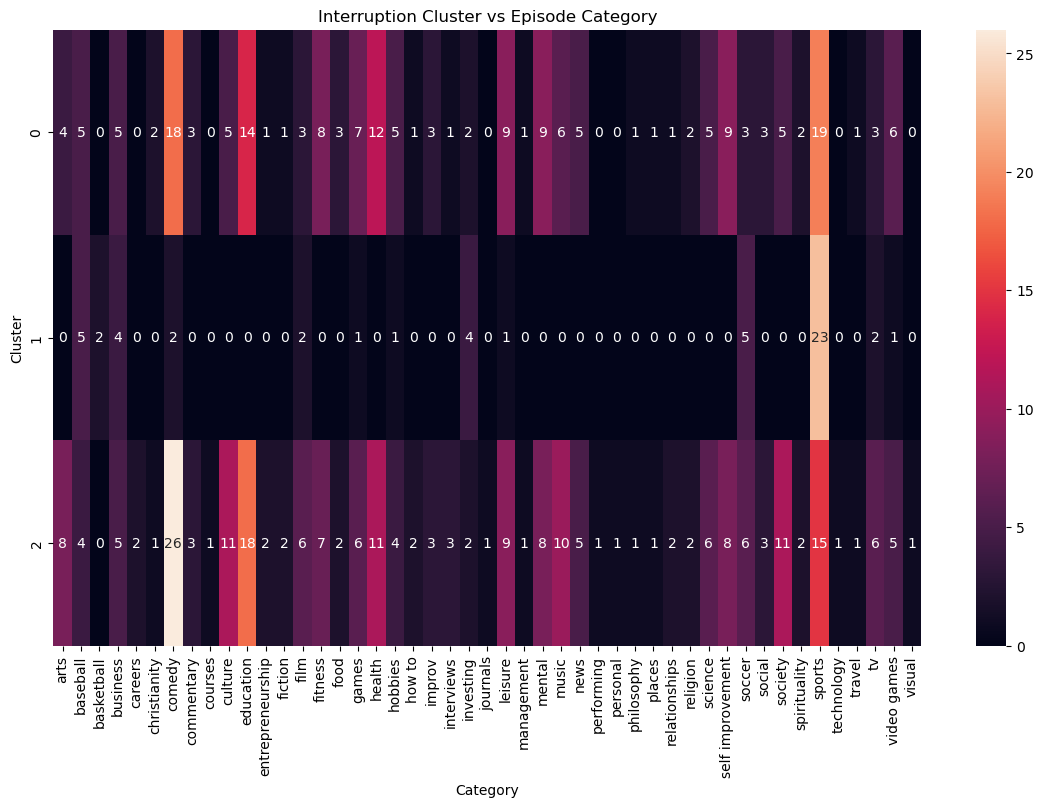

In [49]:
import seaborn as sns
df = pd.DataFrame({
    "kmeans_cluster": kmeans_labels,
    "dbscan_cluster": dbscan_labels,
    "episode_id": episode_id,
})

# Convert categories_per_episode list to a dictionary for mapping
episode_to_categories = {i: categories_per_episode[i] for i in range(len(categories_per_episode))}
df["category"] = df["episode_id"].map(episode_to_categories)

# Since each episode has multiple categories, explode the category column
df = df.explode("category")
df = df[df["category"].str.strip() != ""]
table = pd.crosstab(df["kmeans_cluster"], df["category"])
#add total number of interruptions per cluster
table["Total Interruptions"] = table.sum(axis=1)
display(table)

plt.figure(figsize=(14, 8))
#should print before total interruptions
sns.heatmap(table.drop(columns=["Total Interruptions"]), annot=True, fmt="d")
plt.title("Interruption Cluster vs Episode Category")
plt.xlabel("Category")
plt.ylabel("Cluster")
plt.show()